In [1]:
# %matplotlib widget
from hikyuu.interactive import *
from Strategy.sg.Divergence import *


#创建一个从2022年4月1日开始的账户，初始资金100万元
my_tm = crtTM(date = Datetime(201204010000), init_cash = 1000000, cost_func=TC_FixedA(commission=0.0001, lowest_commission=5.0))
#不做仓位管理，全仓买进卖出
# my_mm = crtMM(MM_Nothing,{'auto-checkin':True})
my_mm = MM_Nothing()
# my_mm = MM_FixedCount()
#回测时间设定
query = Query(Datetime(201204010000), Datetime(202604010000), ktype = 'DAY', recover_type = Query.BACKWARD)

#回测标的限定
s = sm['sz300408']



my_sg = crtSG(SKDJDivergenceSG, 
              {'n': 9, 'm': 3, 'oversold': 55, 'overbought': 50, 'lookback': 20, 'window':4 ,'alternate':False, 'support_borrow_stock': True}, 
              'SKDJ背离策略')


sys = SYS_Simple(tm = my_tm, mm = my_mm, sg = my_sg)
sys.run(s, query)




2026-04-29 18:23:40,730 [INFO] runing in interactive session [<module>] (c:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu\__init__.py:145) [hikyuu::hku_info]
2026-04-29 18:23:40,732 [INFO] running in jupyter [<module>] (c:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu\__init__.py:152) [hikyuu::hku_info]


2026-04-29 18:23:40.740 [HKU-I] - 插件路径: c:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu_plugin (StockManager.cpp:110)
2026-04-29 18:23:40.745 [HKU-I] - Using SQLITE3 BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-04-29 18:23:40.747 [HKU-I] - 加载市场信息…… (StockManager.cpp:795)
2026-04-29 18:23:40.748 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:812)
2026-04-29 18:23:40.749 [HKU-I] - 加载证券信息…… (StockManager.cpp:693)
2026-04-29 18:23:40.903 [HKU-I] - 加载权息数据…… (StockManager.cpp:829)
2026-04-29 18:23:41.098 [HKU-I] - 加载板块信息…… (StockManager.cpp:184)
2026-04-29 18:23:41.206 [HKU-I] - 加载K线数据…… (StockManager.cpp:188)
2026-04-29 18:23:41.207 [HKU-I] - 预加载 month K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-29 18:23:41.208 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-29 18:23:41.209 [HKU-I] - 预加载 week K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-29 18:23:41.209 [HKU-I] - 预加载 year K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-29 18:23:41.21

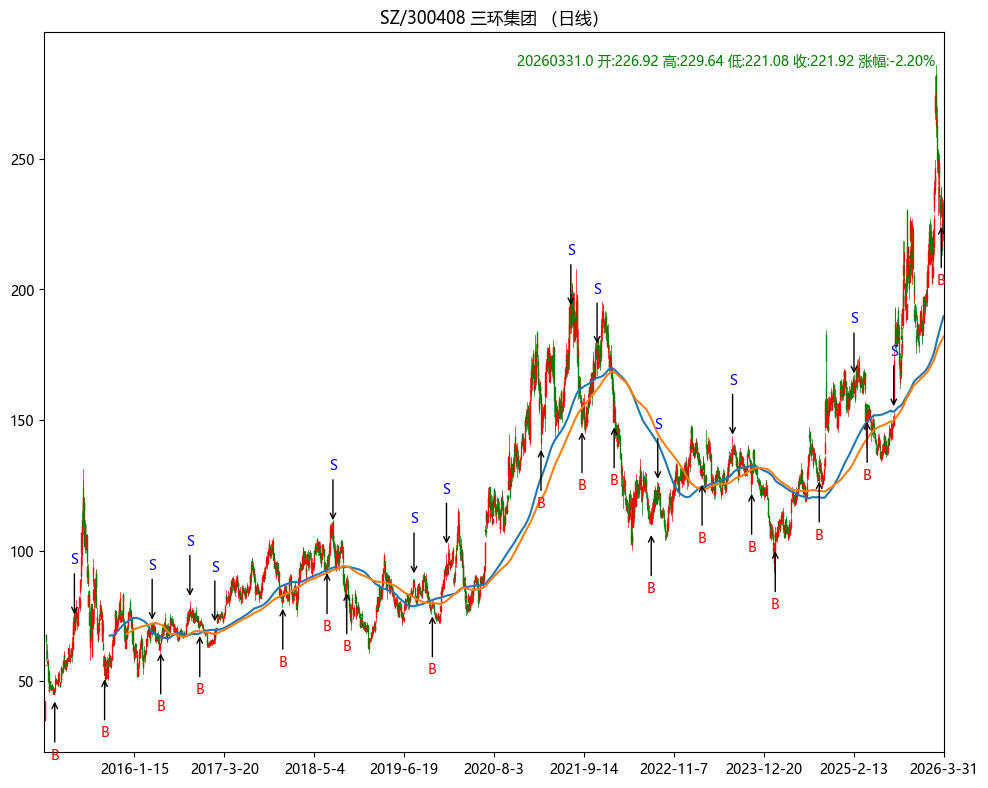

In [2]:
sys.plot()
MA(CLOSE(sys.to), n = 200).plot(new=False)
MA(CLOSE(sys.to), n = 250).plot(new=False)

<Axes: title={'center': '账户(SYS) 累积收益率'}>

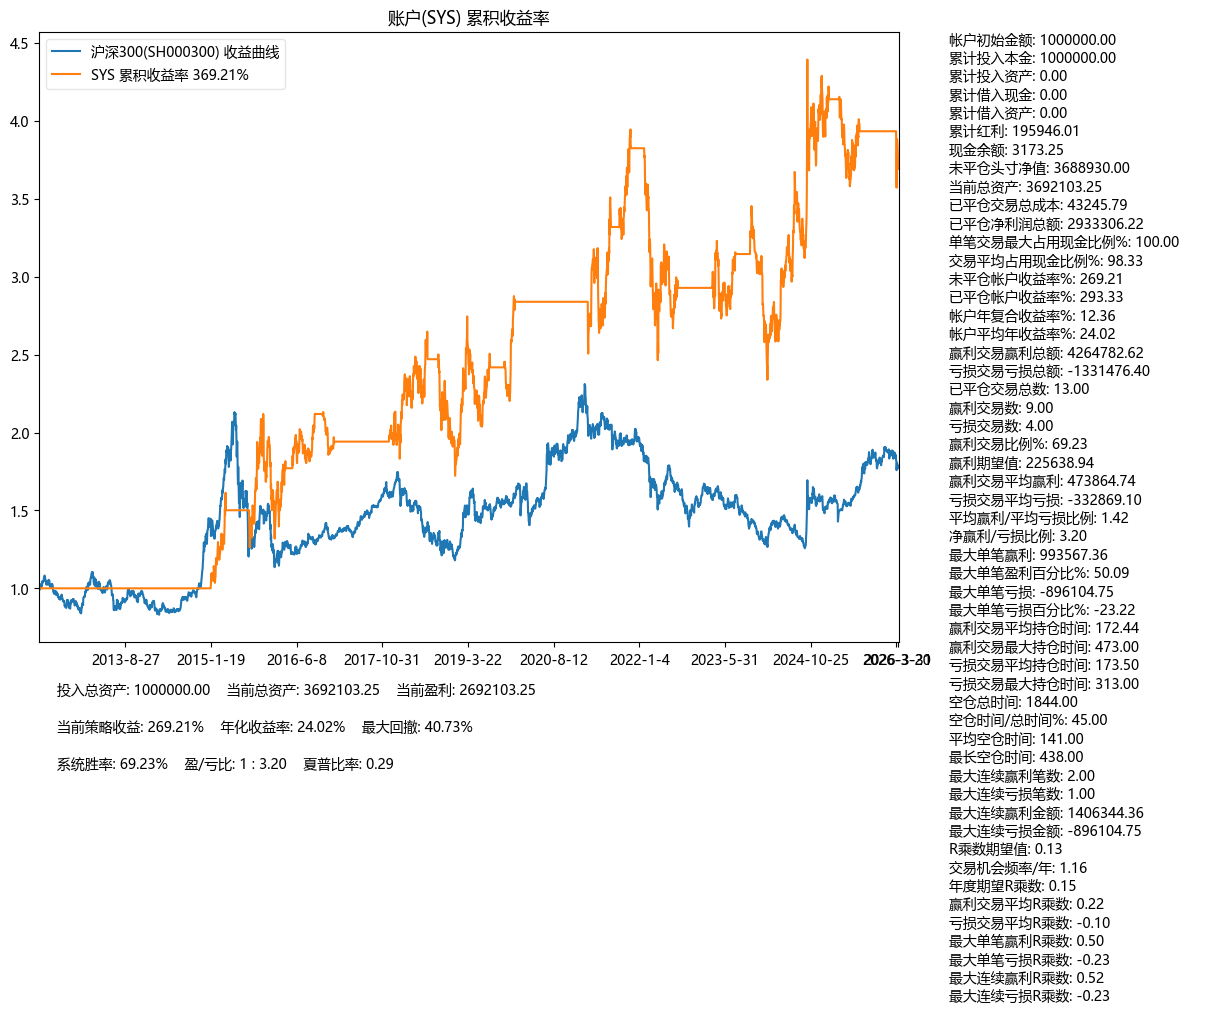

In [5]:
sys.performance()

C:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu\draw\drawplot\matplotlib_draw.py:482: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = axes.legend(loc='upper left')


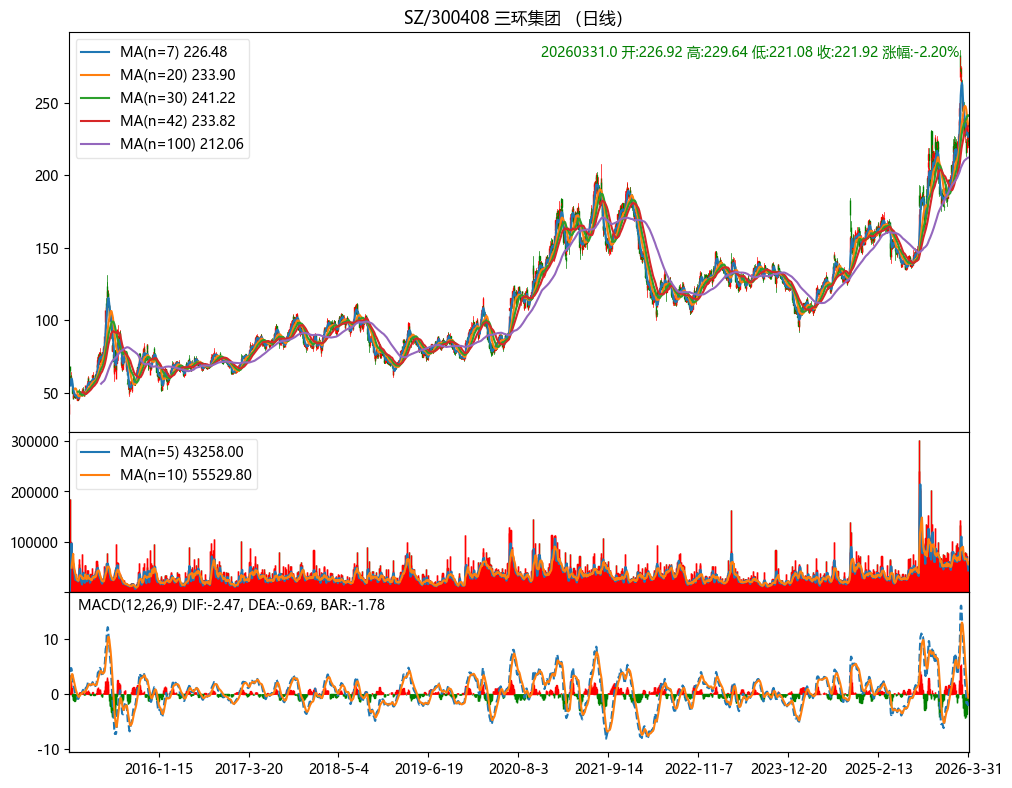

In [2]:
vl.draw2(s,query)